# NEXTBUY — De la donnée brute à la décision intelligente

> *« Le monde ne peut pas être compris sans les chiffres. Mais il ne peut pas non plus être compris avec les chiffres seuls. »*  
> — Hans Rosling, Factfulness

---

## Présentation du projet

Ce notebook réalise une **Analyse Exploratoire des Données (EDA)** complète et construit des **modèles de machine learning prédictifs** sur le jeu de données de courses en ligne Instacart.  
Le jeu de données contient des millions de commandes passées par des milliers de clients. Chaque client passe une ou plusieurs commandes, chaque commande contient un ou plusieurs produits, les produits appartiennent à des rayons, et les rayons appartiennent à des départements.

### Fichiers de données attendus

| Fichier      | Description                                                                     |
|--------------|---------------------------------------------------------------------------------|
| `orders.csv` | Métadonnées des commandes (utilisateur, horaire, jour, heure) |
| `order_products.csv` | Produits par commande (position dans le panier, flag de réachat) |
| `products.csv` | Catalogue produits |
| `aisles.csv` | Noms des rayons |
| `departments.csv` | Noms des départements |

### Questions business traitées

1. Quels sont les produits les plus vendus ?
2. Quand et comment les clients commandent-ils ?
3. Quel est le taux de réachat par département ?
4. Quelle proportion des commandes de légumes est bio ?
5. Quel produit les clients ajoutent-ils en premier dans leur panier ?
6. Quels rayons et départements ont le plus de produits ?
7. Existe-t-il un lien entre le délai de retour et la probabilité de réachat ?
8. Quels produits sont fréquemment achetés ensemble ?
9. Quels sont les principaux profils d'achat des clients ?
10. Quelle est la distribution des tailles de panier ?

---

---
## 0. Configuration de l'environnement

Toutes les bibliothèques utilisées sont des packages Python standard. Décommentez la cellule suivante si certains packages sont manquants.

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

## Installation des dépendances optionnelles

Avant de lancer ce notebook, assurez-vous d'avoir installé `jinja2` pour l'affichage stylisé des tableaux :

pip install jinja2

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.titlesize': 14,
})
sns.set_style('whitegrid')

---
## 1. Chargement et prétraitement des données

Nous chargeons les cinq fichiers CSV, les inspectons, puis les fusionnons en un seul DataFrame enrichi.  
**Placez tous les fichiers CSV dans le même répertoire que ce notebook** (ou modifiez `DATA_DIR` ci-dessous).

In [3]:
DATA_DIR = '.'

def charger_csv(nom_fichier, **kwargs):
    chemin = os.path.join(DATA_DIR, nom_fichier)
    if not os.path.exists(chemin):
        raise FileNotFoundError(
            f"'{nom_fichier}' introuvable dans '{DATA_DIR}'.\n"
            f"Placez tous les fichiers CSV à côté de ce notebook."
        )
    df = pd.read_csv(chemin, **kwargs)
    print(f'  {nom_fichier:<35} {df.shape[0]:>10,} lignes  x  {df.shape[1]} colonnes')
    return df

print('Chargement des données...')
orders          = charger_csv('orders.csv')
order_products  = charger_csv('order_products.csv')
products        = charger_csv('products.csv')
aisles          = charger_csv('aisles.csv')
departments     = charger_csv('departments.csv')

Chargement des données...
  orders.csv                           1,444,444 lignes  x  6 colonnes
  order_products.csv                  13,692,886 lignes  x  4 colonnes
  products.csv                            49,688 lignes  x  4 colonnes
  aisles.csv                                 134 lignes  x  2 colonnes
  departments.csv                             21 lignes  x  2 colonnes


In [4]:
for nom, df_tmp in [('orders', orders), ('order_products', order_products),
                    ('products', products), ('aisles', aisles), ('departments', departments)]:
    print(f'\n{"-"*50}')
    print(f'{nom}')
    display(df_tmp.head(3))
    print(df_tmp.dtypes.to_string())


--------------------------------------------------
orders


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1.0,1.0,2.0,8.0,NaN
1,2398795,1.0,2.0,3.0,7.0,15.0
2,473747,1.0,3.0,3.0,12.0,21.0


order_id                    int64
user_id                   float64
order_number              float64
order_dow                 float64
order_hour_of_day         float64
days_since_prior_order    float64

--------------------------------------------------
order_products


,order_id,product_id,add_to_cart_order,reordered
0,2,33120.0,1.0,1.0
1,2,28985.0,2.0,1.0
2,2,9327.0,3.0,0.0


order_id               int64
product_id           float64
add_to_cart_order    float64
reordered            float64

--------------------------------------------------
products


...

product_id       int64
product_name       str
aisle_id         int64
department_id    int64

--------------------------------------------------
aisles


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars


aisle_id    int64
aisle         str

--------------------------------------------------
departments


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


department_id    int64
department         str


In [5]:
order_products = order_products.dropna(subset=['product_id', 'add_to_cart_order', 'reordered'])

order_products['product_id']        = order_products['product_id'].astype(int)
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)
order_products['reordered']         = order_products['reordered'].astype(int)

print(f"Missing days_since_prior_order: {orders['days_since_prior_order'].isna().sum():,} "
      f"({orders['days_since_prior_order'].isna().mean()*100:.1f}%) — premières commandes, attendu.")

orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)

print(f'Doublons — orders : {orders.duplicated().sum()} | order_products : {order_products.duplicated().sum()}')
print('Nettoyage termine.')

Missing days_since_prior_order: 86,909 (6.0%) — premières commandes, attendu.
Doublons — orders : 0 | order_products : 0
Nettoyage termine.


In [6]:
df = (
    order_products
    .merge(orders,      on='order_id',      how='left')
    .merge(products,    on='product_id',    how='left')
    .merge(aisles,      on='aisle_id',      how='left')
    .merge(departments, on='department_id', how='left')
)

print(f'Dimensions du DataFrame enrichi : {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')
df.head(3)

Dimensions du DataFrame enrichi : (13691542, 14)
Colonnes : ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104,13,spices seasonings,pantry


In [7]:
n_clients   = orders['user_id'].nunique()
n_commandes = orders['order_id'].nunique()
n_produits  = products['product_id'].nunique()
n_rayons    = aisles['aisle_id'].nunique()
n_depts     = departments['department_id'].nunique()
taille_moy  = order_products.groupby('order_id').size().mean()

print('='*45)
print(f'  Clients uniques          : {n_clients:>10,}')
print(f'  Commandes totales        : {n_commandes:>10,}')
print(f'  Produits uniques         : {n_produits:>10,}')
print(f'  Rayons                   : {n_rayons:>10,}')
print(f'  Departements             : {n_depts:>10,}')
print(f'  Articles moyens/commande : {taille_moy:>10.2f}')
print('='*45)

  Clients uniques          :    201,117
  Commandes totales        :  1,444,444
  Produits uniques         :     49,688
  Rayons                   :        134
  Departements             :         21
  Articles moyens/commande :      10.09


---
## 2. Analyse Exploratoire des Données

Nous répondons aux 10 questions business à l'aide de résumés statistiques et de visualisations appropriées.

### Question 1 — Quels sont les produits les plus vendus ?

**Valeur business :** Connaître les meilleurs produits guide le placement en rayon, la gestion des stocks et les priorités promotionnelles.

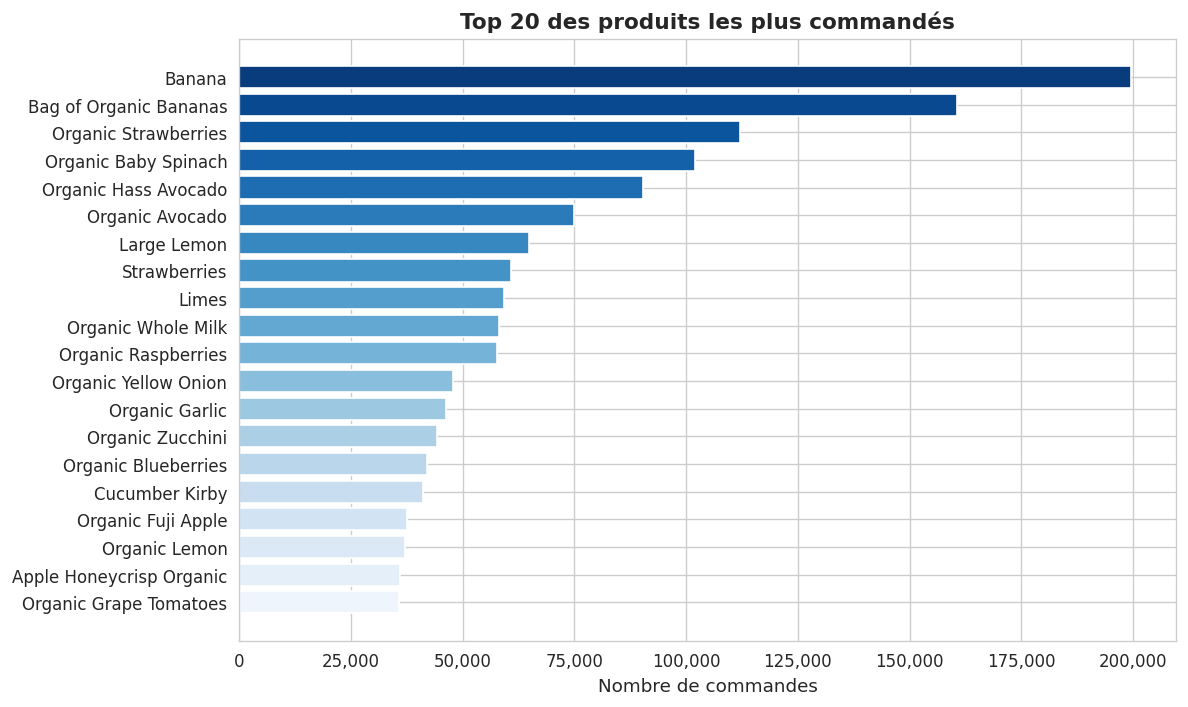

Conclusion : Les bananes et les produits bio frais dominent le classement — les articles frais et sains tirent les volumes de vente.


In [8]:
top_produits = (
    df.groupby('product_name')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'order_id': 'nb_commandes'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_produits['product_name'][::-1],
    top_produits['nb_commandes'][::-1],
    color=sns.color_palette('Blues', 20)
)
ax.set_xlabel('Nombre de commandes')
ax.set_title('Top 20 des produits les plus commandés', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Conclusion : Les bananes et les produits bio frais dominent le classement —'
      ' les articles frais et sains tirent les volumes de vente.')

### Question 2 — Quand et comment les clients commandent-ils ?

**Valeur business :** La planification des effectifs, les notifications ciblées et le calendrier des ventes flash bénéficient tous de la connaissance des pics de commandes.

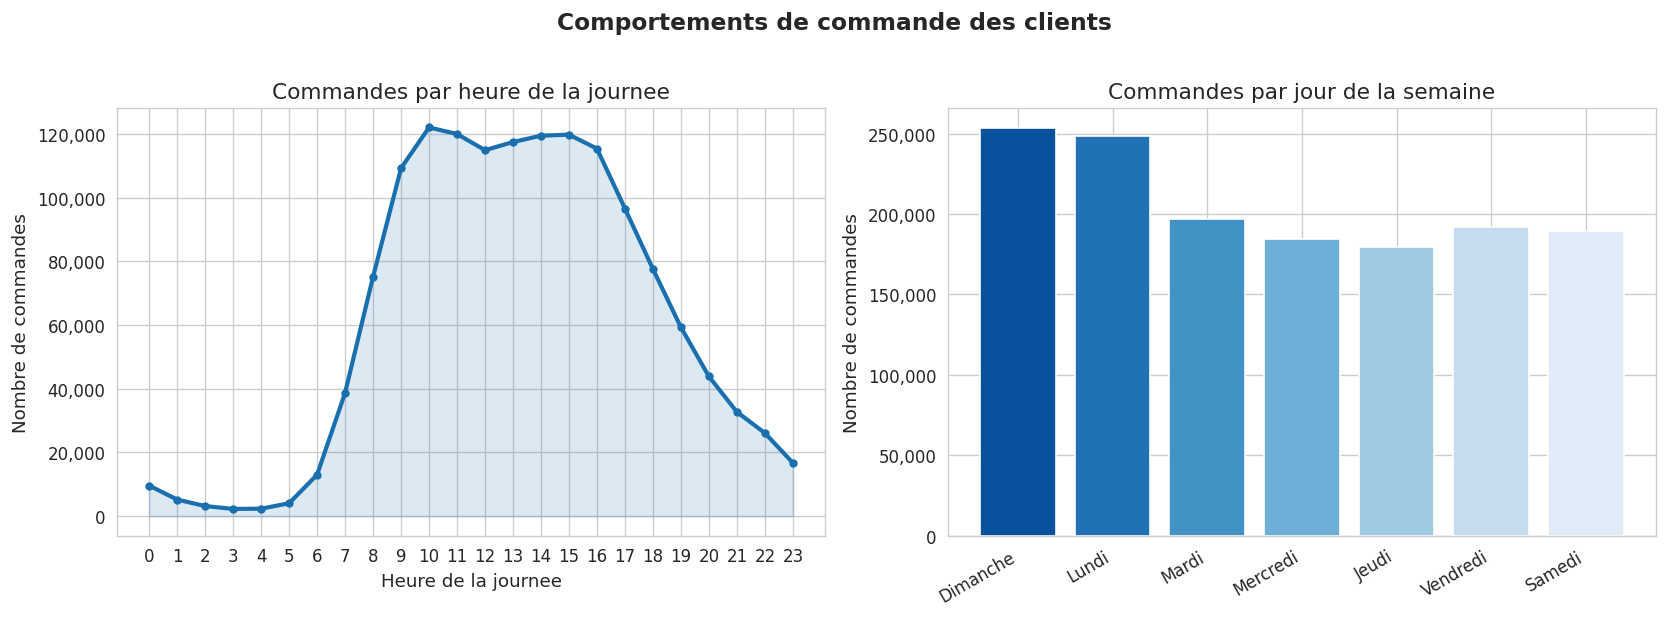

Conclusion : Le pic de commandes se situe a 10.0h le Dimanche — moment ideal pour lancer des promotions.


In [9]:
orders_uniques = orders.drop_duplicates(subset='order_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

commandes_par_heure = orders_uniques['order_hour_of_day'].value_counts().sort_index()
axes[0].plot(commandes_par_heure.index, commandes_par_heure.values,
             color='#1a6faf', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(commandes_par_heure.index, commandes_par_heure.values,
                     alpha=0.15, color='#1a6faf')
axes[0].set_xlabel("Heure de la journee")
axes[0].set_ylabel('Nombre de commandes')
axes[0].set_title('Commandes par heure de la journee')
axes[0].set_xticks(range(0, 24))

jours_labels = ['Dimanche', 'Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi']
commandes_par_jour = orders_uniques['order_dow'].value_counts().sort_index()
axes[1].bar(
    range(7),
    [commandes_par_jour.get(i, 0) for i in range(7)],
    color=sns.color_palette('Blues_r', 7)
)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(jours_labels, rotation=30, ha='right')
axes[1].set_ylabel('Nombre de commandes')
axes[1].set_title('Commandes par jour de la semaine')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Comportements de commande des clients', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

heure_pic = commandes_par_heure.idxmax()
jour_pic = jours_labels[int(commandes_par_jour.idxmax())]
print(f'Conclusion : Le pic de commandes se situe a {heure_pic}h le {jour_pic} —'
      ' moment ideal pour lancer des promotions.')

### Question 3 — Quel est le taux de réachat par département ?

**Valeur business :** Les départements à fort taux de réachat sont des piliers de fidélité. Les départements faibles peuvent bénéficier de campagnes de réengagement.

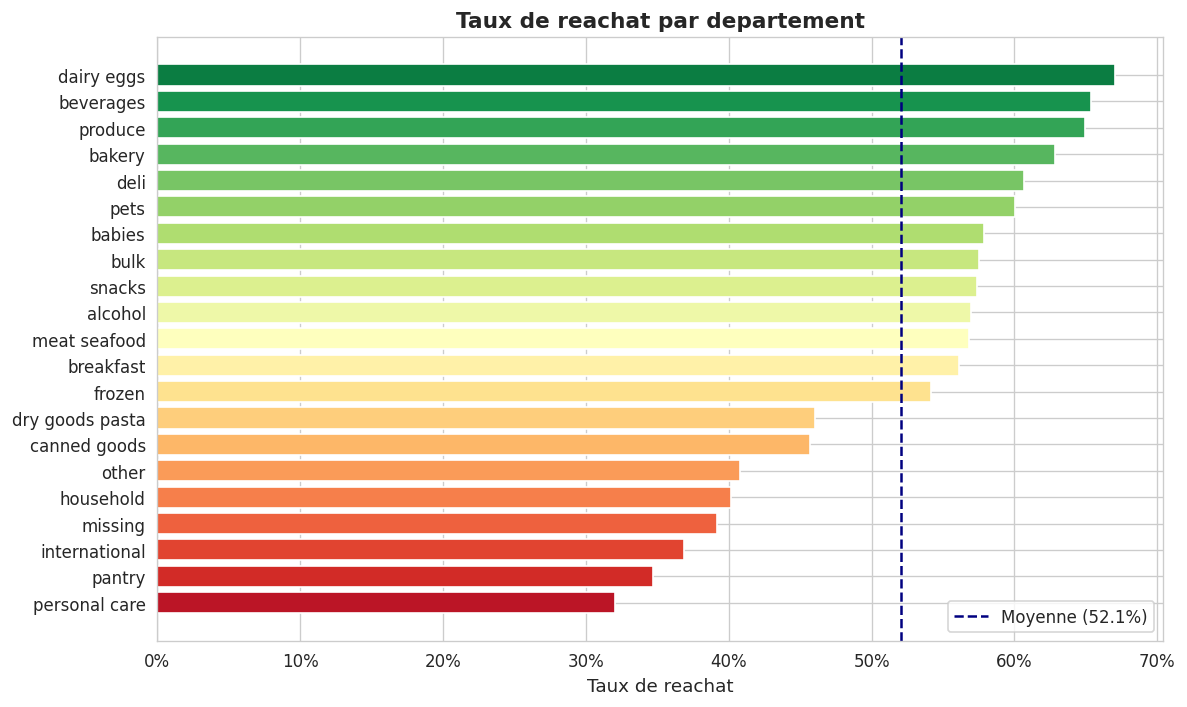

Conclusion : "dairy eggs" affiche le taux de reachat le plus eleve (67.0%) — les clients reviennent de maniere fiable pour les produits frais.


In [10]:
reachat_dept = (
    df.groupby('department')['reordered']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'taux_reachat', 'count': 'nb_articles'})
    .sort_values('taux_reachat', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
couleurs = sns.color_palette('RdYlGn', len(reachat_dept))
ax.barh(
    reachat_dept['department'][::-1],
    reachat_dept['taux_reachat'][::-1],
    color=couleurs
)
ax.axvline(
    x=reachat_dept['taux_reachat'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f'Moyenne ({reachat_dept["taux_reachat"].mean():.1%})'
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Taux de reachat')
ax.set_title('Taux de reachat par departement', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

top_dept = reachat_dept.iloc[0]
print(f'Conclusion : "{top_dept["department"]}" affiche le taux de reachat le plus eleve'
      f' ({top_dept["taux_reachat"]:.1%}) — les clients reviennent de maniere fiable pour les produits frais.')

### Question 4 — Quelle proportion des commandes de légumes est bio ?

**Valeur business :** Mesurer la demande bio permet d'orienter la stratégie d'approvisionnement et l'allocation de l'espace en rayon.

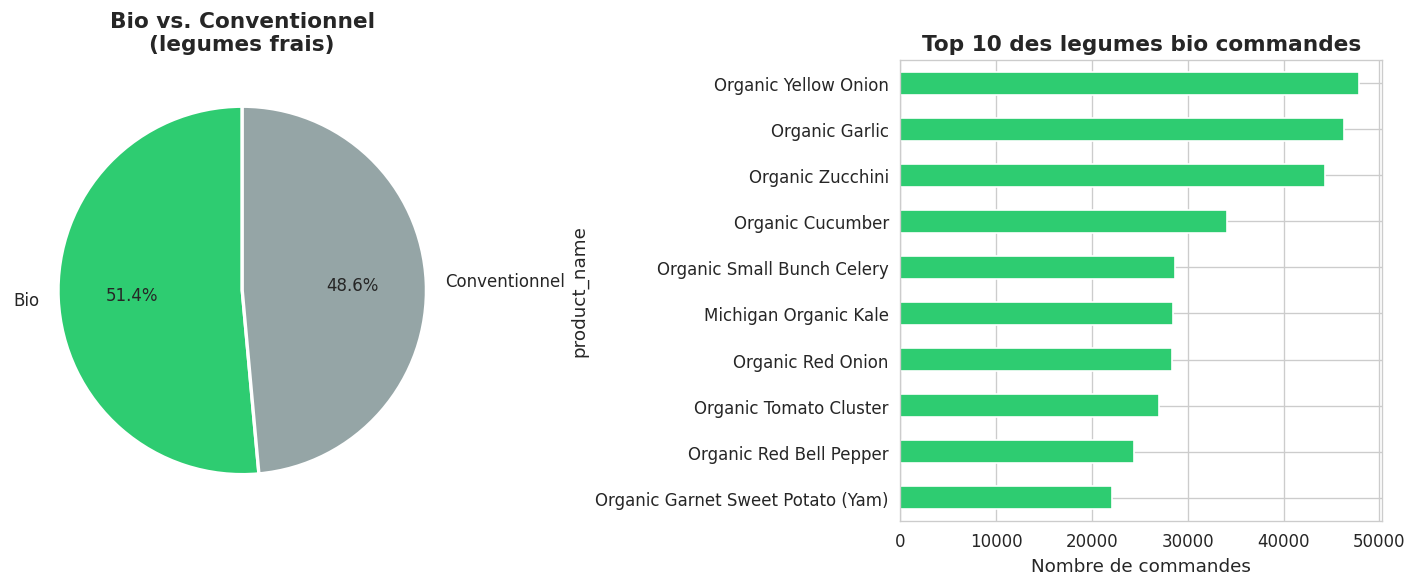

Conclusion : 51.4% des commandes de legumes frais sont bio — signal fort pour elargir la gamme bio et la mettre en avant.


In [11]:
masque_legumes = df['aisle'].str.contains('fresh vegetables', case=False, na=False)
df_legumes = df[masque_legumes].copy()
df_legumes['est_bio'] = df_legumes['product_name'].str.contains('Organic', case=False, na=False)

taux_bio = df_legumes['est_bio'].mean()
comptes  = df_legumes['est_bio'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels_camembert = ['Bio', 'Conventionnel']
valeurs = [comptes.get(True, 0), comptes.get(False, 0)]
axes[0].pie(
    valeurs, labels=labels_camembert,
    colors=['#2ecc71', '#95a5a6'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Bio vs. Conventionnel\n(legumes frais)', fontweight='bold')

top_bio = (
    df_legumes[df_legumes['est_bio']]
    .groupby('product_name')['order_id'].count()
    .sort_values(ascending=False).head(10)
)
top_bio[::-1].plot.barh(ax=axes[1], color='#2ecc71')
axes[1].set_xlabel('Nombre de commandes')
axes[1].set_title('Top 10 des legumes bio commandes', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Conclusion : {taux_bio:.1%} des commandes de legumes frais sont bio —'
      ' signal fort pour elargir la gamme bio et la mettre en avant.')

### Question 5 — Quel produit les clients ajoutent-ils en premier dans leur panier ?

**Valeur business :** Le premier article ajouté révèle l'intention principale du client et peut guider la mise en page de l'application ou du site.

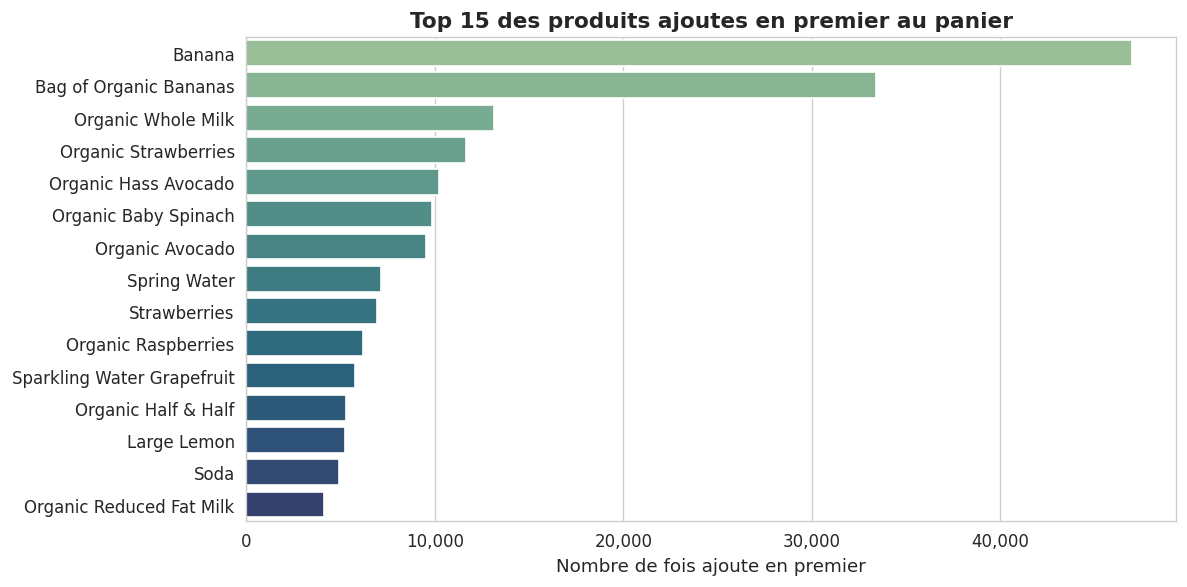

Conclusion : "Banana" est le produit le plus souvent ajoute en premier — les clients arrivent avec un article de base bien defini en tete.


In [12]:
premiers_articles = (
    df[df['add_to_cart_order'] == 1]
    .groupby('product_name')['order_id'].count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={'order_id': 'nb_fois_premier'})
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=premiers_articles,
    y='product_name', x='nb_fois_premier',
    palette='crest', ax=ax
)
ax.set_xlabel('Nombre de fois ajoute en premier')
ax.set_ylabel('')
ax.set_title('Top 15 des produits ajoutes en premier au panier', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f'Conclusion : "{premiers_articles.iloc[0]["product_name"]}" est le produit le plus souvent'
      ' ajoute en premier — les clients arrivent avec un article de base bien defini en tete.')

### Question 6 — Quels rayons et départements ont le plus de produits ?

**Valeur business :** Comprendre la densité du catalogue aide à optimiser la navigation, la recherche et à identifier les catégories sous-exploitées.

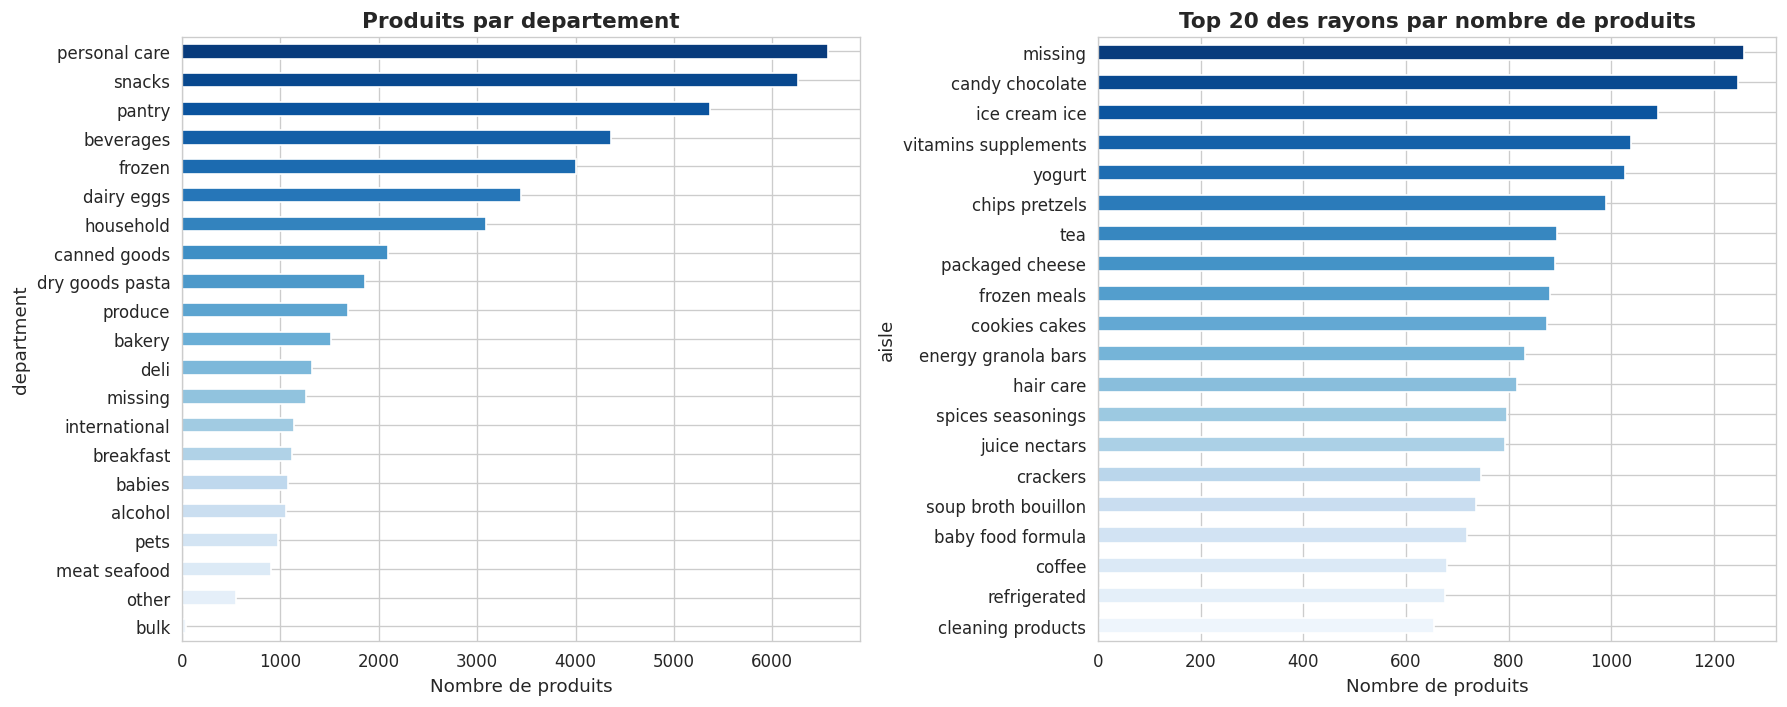

Conclusion : "personal care" est le departement le plus fourni en catalogue — cela reflete la large variete proposee dans cette categorie.


In [13]:
produits_par_dept = (
    products.merge(departments, on='department_id')
    .groupby('department')['product_id'].count()
    .sort_values(ascending=False)
)

produits_par_rayon = (
    products.merge(aisles, on='aisle_id')
    .groupby('aisle')['product_id'].count()
    .sort_values(ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

produits_par_dept.sort_values().plot.barh(
    ax=axes[0],
    color=sns.color_palette('Blues', len(produits_par_dept))
)
axes[0].set_xlabel('Nombre de produits')
axes[0].set_title('Produits par departement', fontweight='bold')

produits_par_rayon[::-1].plot.barh(
    ax=axes[1],
    color=sns.color_palette('Blues', 20)
)
axes[1].set_xlabel('Nombre de produits')
axes[1].set_title('Top 20 des rayons par nombre de produits', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Conclusion : "{produits_par_dept.index[0]}" est le departement le plus fourni en catalogue —'
      ' cela reflete la large variete proposee dans cette categorie.')

### Question 7 — Existe-t-il un lien entre le délai de retour et la probabilité de réachat ?

**Valeur business :** Si les clients qui reviennent rapidement réachètent davantage, il faut cibler les relances sur les acheteurs récents.

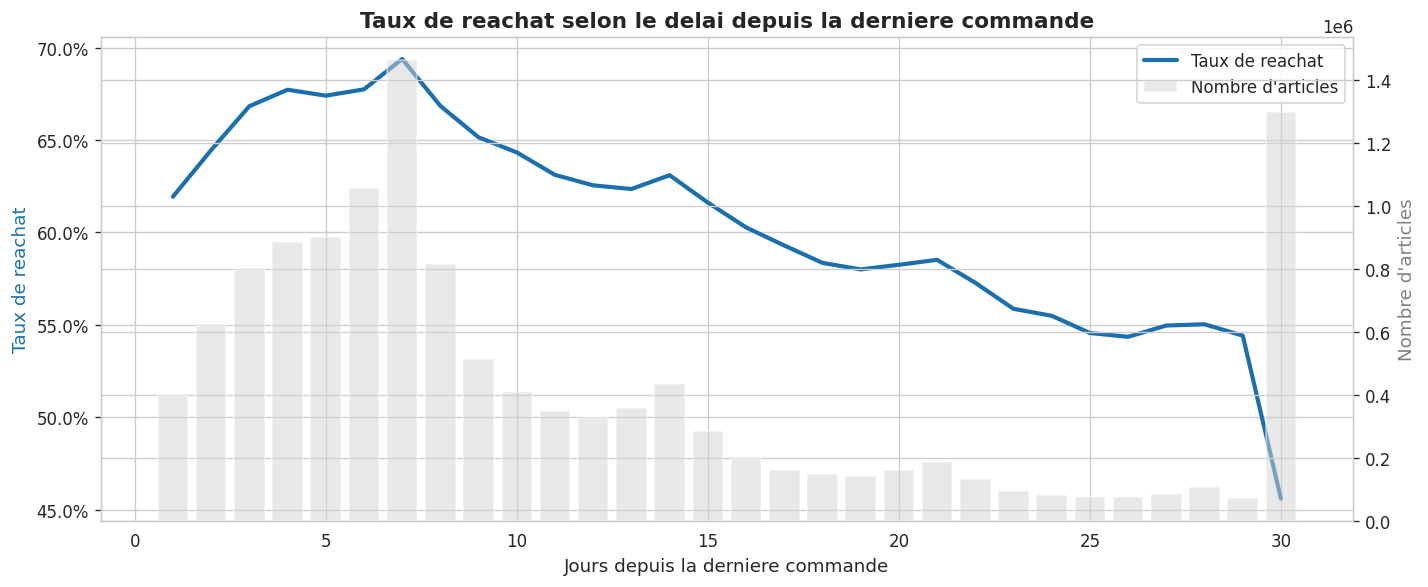

Conclusion : Les taux de reachat sont plus eleves chez les clients qui reviennent a intervalles reguliers (~7, 14, 21, 30 jours) — comportement habituel a renforcer.


In [14]:
delai_reachat = (
    df[df['days_since_prior_order'] > 0]
    .groupby('days_since_prior_order')['reordered']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={
        'mean': 'taux_reachat',
        'count': 'nb_articles',
        'days_since_prior_order': 'jours_depuis_derniere_commande'
    })
)
delai_reachat = delai_reachat[delai_reachat['nb_articles'] >= 100]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(
    delai_reachat['jours_depuis_derniere_commande'],
    delai_reachat['taux_reachat'],
    color='#1a6faf', linewidth=2.5, label='Taux de reachat'
)
ax2.bar(
    delai_reachat['jours_depuis_derniere_commande'],
    delai_reachat['nb_articles'],
    color='lightgray', alpha=0.5, label='Nombre d\'articles'
)
ax1.set_xlabel('Jours depuis la derniere commande')
ax1.set_ylabel('Taux de reachat', color='#1a6faf')
ax2.set_ylabel('Nombre d\'articles', color='gray')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_title('Taux de reachat selon le delai depuis la derniere commande', fontweight='bold')

lignes1, etiq1 = ax1.get_legend_handles_labels()
lignes2, etiq2 = ax2.get_legend_handles_labels()
ax1.legend(lignes1 + lignes2, etiq1 + etiq2, loc='upper right')
plt.tight_layout()
plt.show()

print('Conclusion : Les taux de reachat sont plus eleves chez les clients qui reviennent'
      ' a intervalles reguliers (~7, 14, 21, 30 jours) — comportement habituel a renforcer.')

### Question 8 — Quels produits sont fréquemment achetés ensemble ?

**Valeur business :** Les achats conjoints alimentent la vente croisée, les promotions groupées et les recommandations "les clients ont aussi acheté".

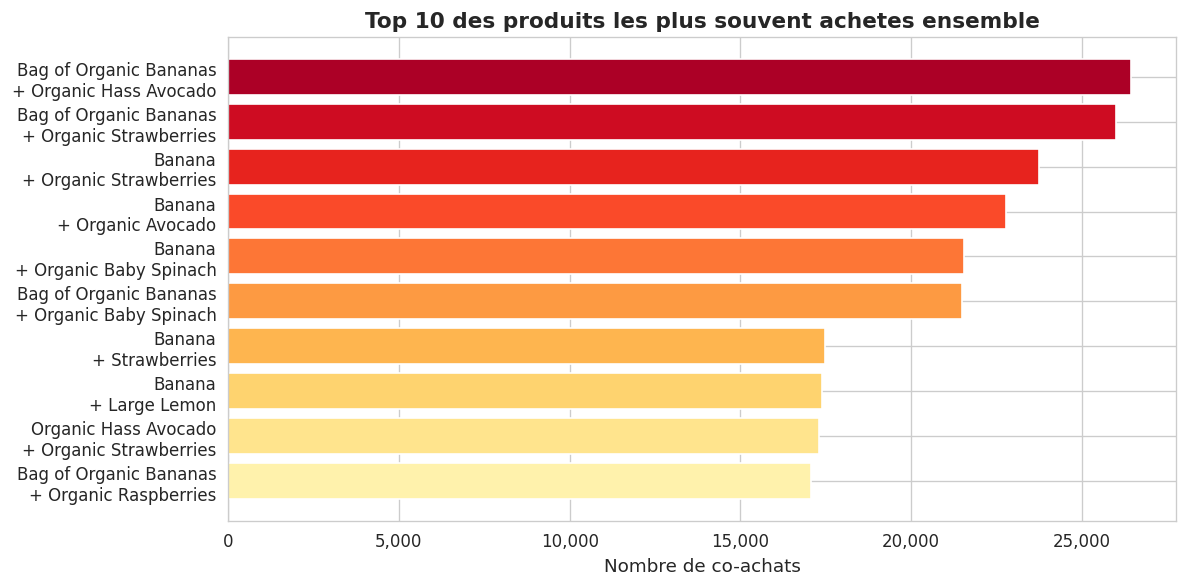

Conclusion : Les paires fortes (souvent bananes + lait/yaourt) suggerent des opportunites de bundling et de placement croise en rayon.


In [15]:
TOP_N = 100
ids_top_produits = (
    df.groupby('product_id')['order_id'].count()
    .sort_values(ascending=False)
    .head(TOP_N).index
)

panier = (
    df[df['product_id'].isin(ids_top_produits)]
    .groupby(['order_id', 'product_name'])['reordered']
    .count()
    .unstack(fill_value=0)
    .clip(upper=1)
)

matrice_co = panier.T.dot(panier)
diag = np.diag(np.diag(matrice_co.values.copy()))
matrice_co = pd.DataFrame(
    matrice_co.values.copy() - diag,
    index=matrice_co.index,
    columns=matrice_co.columns
)
matrice_co.index.name   = 'produit_a'
matrice_co.columns.name = 'produit_b'

paires = (
    matrice_co.stack()
    .reset_index()
    .rename(columns={0: 'nb_co_achats'})
    .query('produit_a < produit_b')
    .sort_values('nb_co_achats', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
etiquettes = [f"{r['produit_a'][:25]}\n+ {r['produit_b'][:25]}" for _, r in paires.iterrows()]
ax.barh(
    etiquettes[::-1],
    paires['nb_co_achats'].values[::-1],
    color=sns.color_palette('YlOrRd', 10)
)
ax.set_xlabel('Nombre de co-achats')
ax.set_title('Top 10 des produits les plus souvent achetes ensemble', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Conclusion : Les paires fortes (souvent bananes + lait/yaourt) suggerent'
      ' des opportunites de bundling et de placement croise en rayon.')

### Question 9 — Quels sont les principaux profils d'achat des clients ?

**Valeur business :** La segmentation des clients par comportement permet un marketing ciblé et des promotions personnalisées.

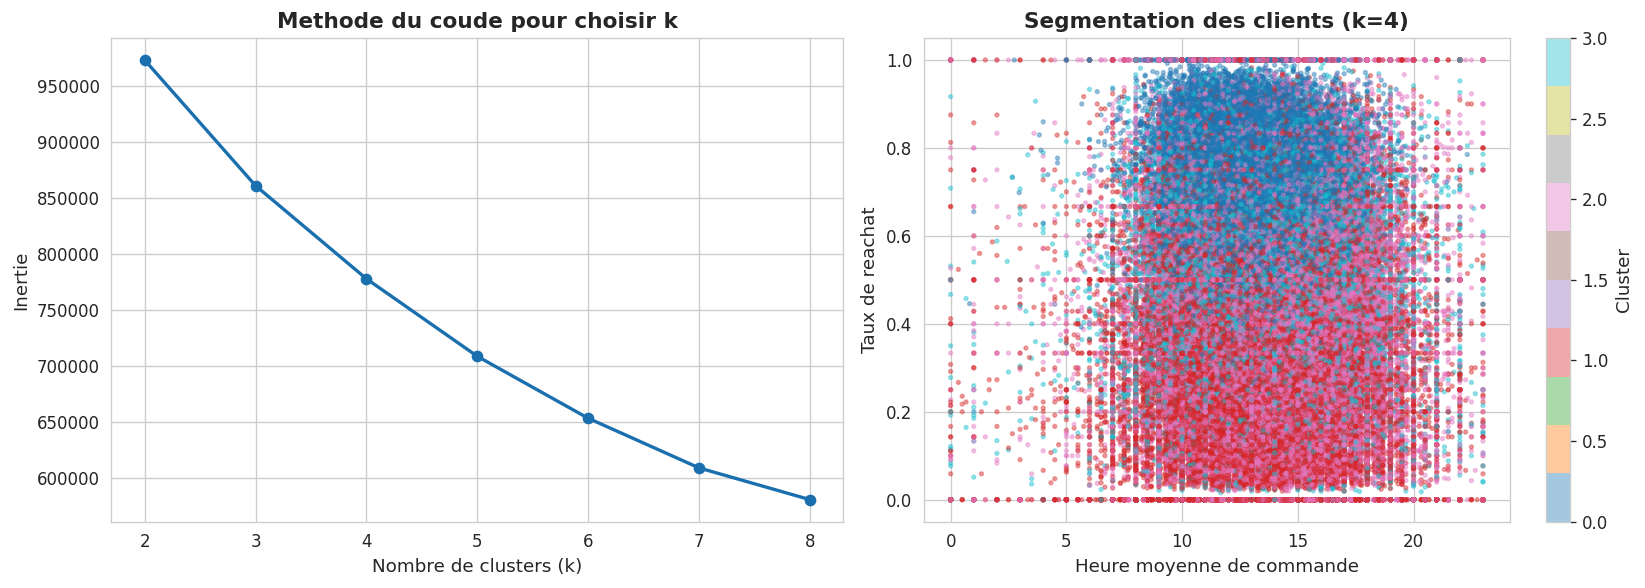

Profils des clusters :


,nb_commandes,heure_moy,jour_moy,delai_moy,taille_panier_moy,taux_reachat
cluster,,,,,,
0,18.96,13.25,2.80,7.50,8.88,0.70
1,4.27,13.56,3.83,13.23,6.72,0.33
2,4.18,13.81,1.75,16.51,6.79,0.39
3,5.96,13.56,2.60,13.36,18.46,0.50


Conclusion : Des groupes distincts emergent — acheteurs nocturnes occasionnels, habitues du matin, gros paniers du week-end, explorateurs a faible frequence.


In [16]:
features_users_commandes = orders.groupby('user_id').agg(
    nb_commandes     = ('order_id',               'count'),
    heure_moy        = ('order_hour_of_day',      'mean'),
    jour_moy         = ('order_dow',              'mean'),
    delai_moy        = ('days_since_prior_order', 'mean'),
).reset_index()

features_users_articles = (
    df.groupby('user_id').agg(
        taille_panier_moy = ('product_id', 'count'),
        taux_reachat      = ('reordered',  'mean'),
    ).reset_index()
)
features_users_articles = features_users_articles.merge(
    features_users_commandes[['user_id', 'nb_commandes']], on='user_id'
)
features_users_articles['taille_panier_moy'] = (
    features_users_articles['taille_panier_moy'] / features_users_articles['nb_commandes']
)

features_users = features_users_commandes.merge(
    features_users_articles.drop(columns='nb_commandes'), on='user_id'
).dropna()

colonnes_features = ['nb_commandes', 'heure_moy', 'jour_moy', 'delai_moy',
                     'taille_panier_moy', 'taux_reachat']
X_users = features_users[colonnes_features].values
scaler_users = StandardScaler()
X_scaled = scaler_users.fit_transform(X_users)

inerties = [
    KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
    for k in range(2, 9)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(2, 9), inerties, 'o-', color='#1a6faf', linewidth=2)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Methode du coude pour choisir k', fontweight='bold')

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
features_users['cluster'] = kmeans.fit_predict(X_scaled)

nuage = axes[1].scatter(
    features_users['heure_moy'],
    features_users['taux_reachat'],
    c=features_users['cluster'],
    cmap='tab10', alpha=0.4, s=5
)
axes[1].set_xlabel('Heure moyenne de commande')
axes[1].set_ylabel('Taux de reachat')
axes[1].set_title(f'Segmentation des clients (k={K})', fontweight='bold')
plt.colorbar(nuage, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

profil = features_users.groupby('cluster')[colonnes_features].mean().round(2)
print('Profils des clusters :')
display(profil)

print('Conclusion : Des groupes distincts emergent — acheteurs nocturnes occasionnels,'
      ' habitues du matin, gros paniers du week-end, explorateurs a faible frequence.')

### Question 10 — Quelle est la distribution des tailles de panier ?

**Valeur business :** Comprendre combien d'articles les gens achètent par commande aide à planifier les niveaux de prix, les offres groupées et la logistique.

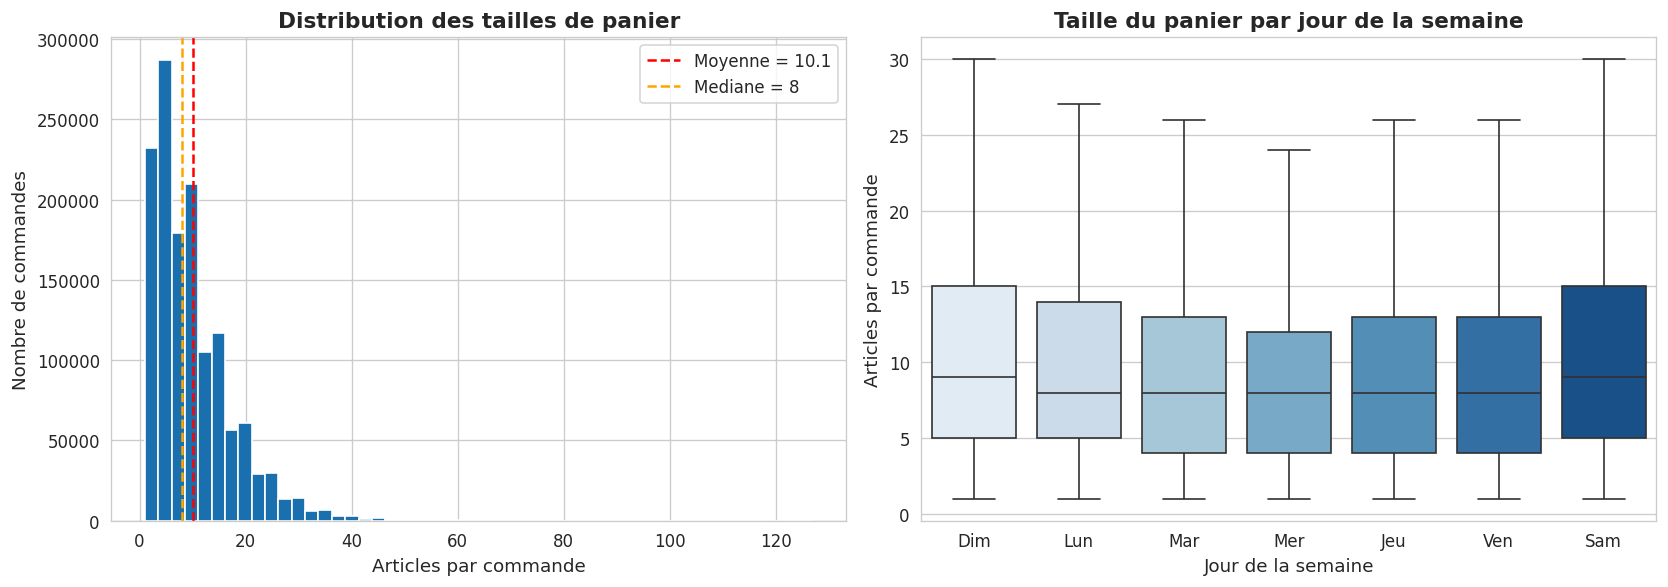

Conclusion : La taille moyenne du panier est de 10.1 articles. Les commandes du week-end tendent a etre legerement plus grandes — les clients preparent la semaine.


In [17]:
tailles_paniers = order_products.groupby('order_id').size().reset_index(name='taille_panier')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tailles_paniers['taille_panier'], bins=50, color='#1a6faf', edgecolor='white')
axes[0].set_xlabel('Articles par commande')
axes[0].set_ylabel('Nombre de commandes')
axes[0].set_title('Distribution des tailles de panier', fontweight='bold')
axes[0].axvline(
    tailles_paniers['taille_panier'].mean(),
    color='red', linestyle='--',
    label=f'Moyenne = {tailles_paniers["taille_panier"].mean():.1f}'
)
axes[0].axvline(
    tailles_paniers['taille_panier'].median(),
    color='orange', linestyle='--',
    label=f'Mediane = {tailles_paniers["taille_panier"].median():.0f}'
)
axes[0].legend()

dow_panier = orders.merge(tailles_paniers, on='order_id').dropna(subset=['order_dow'])
jours_courts = ['Dim', 'Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam']
dow_panier['nom_jour'] = dow_panier['order_dow'].map(lambda x: jours_courts[int(x)])

sns.boxplot(
    data=dow_panier, x='nom_jour', y='taille_panier',
    order=jours_courts, palette='Blues',
    ax=axes[1], showfliers=False
)
axes[1].set_xlabel('Jour de la semaine')
axes[1].set_ylabel('Articles par commande')
axes[1].set_title('Taille du panier par jour de la semaine', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Conclusion : La taille moyenne du panier est de'
      f' {tailles_paniers["taille_panier"].mean():.1f} articles.'
      ' Les commandes du week-end tendent a etre legerement plus grandes —'
      ' les clients preparent la semaine.')

---
## 3. Machine Learning — Prédiction des réachats

**Objectif :** Prédire si une combinaison (utilisateur x produit) sera **réachetée** lors d'une prochaine commande.  
Il s'agit d'un problème de **classification binaire** (`reordered = 1` vs `0`).

### Ingénierie des features

Nous construisons des features au niveau du **produit** et de l'**utilisateur** pour capturer les habitudes d'achat.

In [18]:
features_produits = (
    df.groupby('product_id').agg(
        nb_commandes_produit   = ('order_id',          'count'),
        taux_reachat_produit   = ('reordered',         'mean'),
        pos_panier_moy_produit = ('add_to_cart_order', 'mean'),
    ).reset_index()
)

features_utilisateurs = (
    df.groupby('user_id').agg(
        nb_commandes_user      = ('order_id',               pd.Series.nunique),
        taille_panier_moy_user = ('product_id',             'count'),
        taux_reachat_user      = ('reordered',              'mean'),
        heure_moy_user         = ('order_hour_of_day',      'mean'),
        delai_moy_user         = ('days_since_prior_order', 'mean'),
    ).reset_index()
)

df_ml = (
    df[['order_id', 'product_id', 'user_id', 'reordered',
        'add_to_cart_order', 'order_hour_of_day', 'order_dow', 'days_since_prior_order']]
    .merge(features_produits,     on='product_id', how='left')
    .merge(features_utilisateurs, on='user_id',    how='left')
    .dropna()
)

COLONNES_FEATURES = [
    'nb_commandes_produit', 'taux_reachat_produit', 'pos_panier_moy_produit',
    'nb_commandes_user', 'taille_panier_moy_user', 'taux_reachat_user',
    'heure_moy_user', 'delai_moy_user',
    'add_to_cart_order', 'order_hour_of_day', 'order_dow', 'days_since_prior_order'
]
CIBLE = 'reordered'

X = df_ml[COLONNES_FEATURES]
y = df_ml[CIBLE]

print(f'Donnees pour le ML : {X.shape[0]:,} exemples, {X.shape[1]} features')
print(f'Equilibre des classes — reachat : {y.mean():.1%} | non-reachat : {1-y.mean():.1%}')

Donnees pour le ML : 13,690,784 exemples, 12 features
Equilibre des classes — reachat : 59.0% | non-reachat : 41.0%


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ensemble d\'entrainement : {X_train.shape[0]:,} exemples')
print(f'Ensemble de test        : {X_test.shape[0]:,} exemples')

Ensemble d'entrainement : 10,952,627 exemples
Ensemble de test        : 2,738,157 exemples


### Modele 1 — Regression Logistique (reference)

Modele lineaire simple et interpretable. Rapide a entrainer, fournit des probabilites bien calibrees.  
Utilise comme **reference** pour comparer avec des modeles plus puissants.

In [20]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=500, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]

print('=== Regression Logistique ===')
print(classification_report(y_test, y_pred_lr))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Regression Logistique ===
              precision    recall  f1-score   support

           0       0.71      0.60      0.65   1123771
           1       0.75      0.83      0.79   1614386

    accuracy                           0.74   2738157
   macro avg       0.73      0.71      0.72   2738157
weighted avg       0.73      0.74      0.73   2738157

ROC-AUC : 0.7997


### Modele 2 — Foret Aleatoire

Ensemble d'arbres de decision. Gere les relations non lineaires, est robuste aux valeurs aberrantes et fournit des scores d'importance des features.  
Surpasse generalement la regression logistique sur les donnees tabulaires.

In [21]:
clf_rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=50,
    n_jobs=-1, random_state=42
)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]

print('=== Foret Aleatoire ===')
print(classification_report(y_test, y_pred_rf))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Foret Aleatoire ===
              precision    recall  f1-score   support

           0       0.75      0.59      0.66   1123771
           1       0.75      0.86      0.80   1614386

    accuracy                           0.75   2738157
   macro avg       0.75      0.73      0.73   2738157
weighted avg       0.75      0.75      0.74   2738157

ROC-AUC : 0.8183


### Modele 3 — Gradient Boosting

Construit des arbres de maniere sequentielle, chacun corrigeant les erreurs du precedent.  
Generalement le modele le plus performant sur les donnees structurees, notamment pour capturer les interactions complexes entre features.

In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

clf_gb = HistGradientBoostingClassifier(max_iter=100, max_depth=5, random_state=42)

clf_gb.fit(X_train, y_train)
y_pred_gb = clf_gb.predict(X_test)
y_prob_gb = clf_gb.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting ===')
print(classification_report(y_test, y_pred_gb))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_gb):.4f}')

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.74      0.62      0.68   1123771
           1       0.76      0.85      0.80   1614386

    accuracy                           0.76   2738157
   macro avg       0.75      0.73      0.74   2738157
weighted avg       0.75      0.76      0.75   2738157

ROC-AUC : 0.8257


### Comparaison des modeles

,Exactitude,Score F1,ROC-AUC
Modele,,,
Regression Logistique,0.735500,0.787500,0.799700
Foret Aleatoire,0.750400,0.802600,0.818300
Gradient Boosting,0.755700,0.804300,0.825700


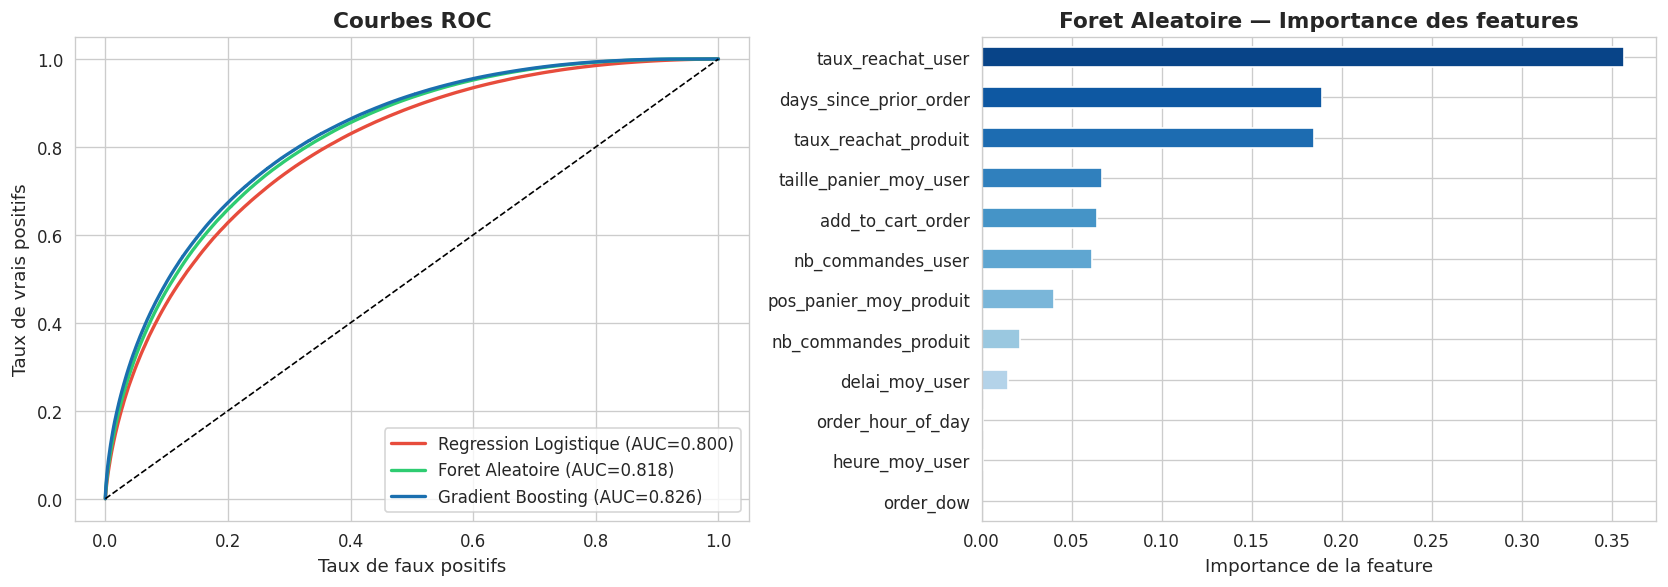

Meilleur modele par ROC-AUC : Gradient Boosting
Conclusion : Le taux de reachat produit et le taux de reachat utilisateur sont les features les plus predictives — le comportement passe est le meilleur indicateur des achats futurs.


In [23]:
resultats = pd.DataFrame({
    'Modele': ['Regression Logistique', 'Foret Aleatoire', 'Gradient Boosting'],
    'Exactitude': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
    ],
    'Score F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
    ],
})

display(resultats.set_index('Modele').round(4).style.highlight_max(color='lightgreen'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nom, y_prob, couleur in [
    ('Regression Logistique', y_prob_lr, '#e74c3c'),
    ('Foret Aleatoire',       y_prob_rf, '#2ecc71'),
    ('Gradient Boosting',     y_prob_gb, '#1a6faf'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{nom} (AUC={auc:.3f})', color=couleur, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].set_title('Courbes ROC', fontweight='bold')
axes[0].legend()

importances = pd.Series(clf_rf.feature_importances_, index=COLONNES_FEATURES).sort_values()
importances.plot.barh(ax=axes[1], color=sns.color_palette('Blues', len(COLONNES_FEATURES)))
axes[1].set_xlabel('Importance de la feature')
axes[1].set_title('Foret Aleatoire — Importance des features', fontweight='bold')

plt.tight_layout()
plt.show()

meilleur_modele = resultats.loc[resultats['ROC-AUC'].idxmax(), 'Modele']
print(f'Meilleur modele par ROC-AUC : {meilleur_modele}')
print('Conclusion : Le taux de reachat produit et le taux de reachat utilisateur sont les features'
      ' les plus predictives — le comportement passe est le meilleur indicateur des achats futurs.')

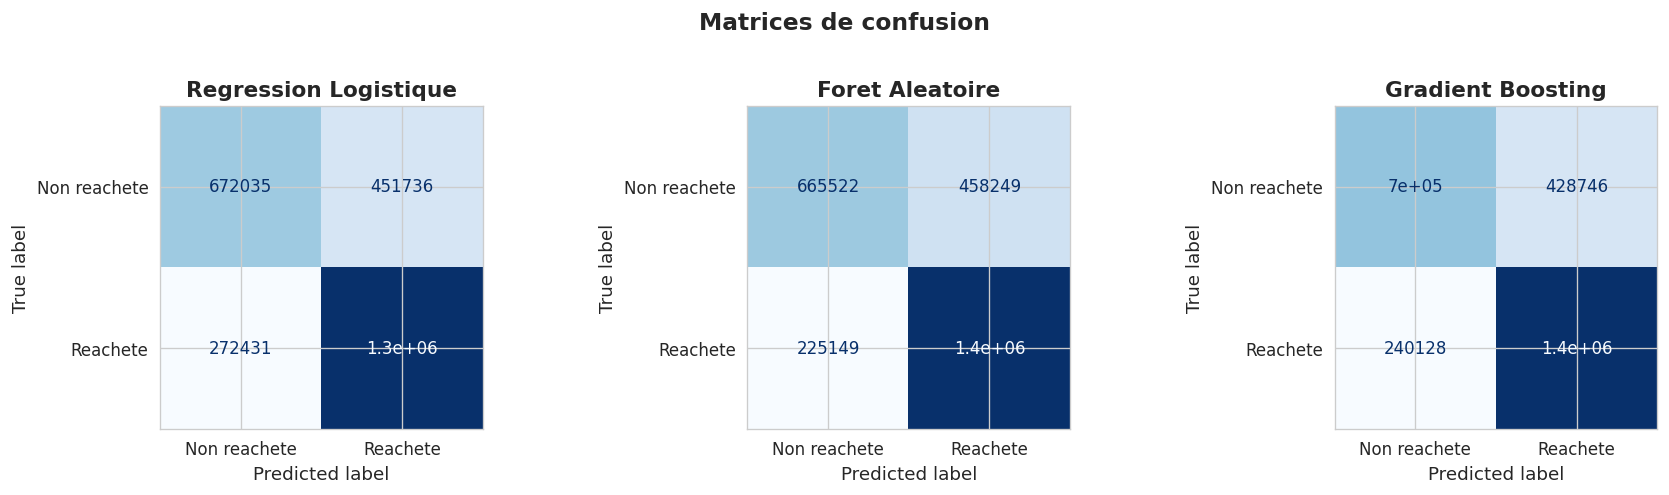

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nom, y_pred) in zip(axes, [
    ('Regression Logistique', y_pred_lr),
    ('Foret Aleatoire',       y_pred_rf),
    ('Gradient Boosting',     y_pred_gb),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non reachete', 'Reachete']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nom, fontweight='bold')

plt.suptitle('Matrices de confusion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Conclusion et recommandations business
| N | Question | Constat principal | Action recommandée |
|---|----------|-------------------|--------------------|
| 1 | Meilleures ventes | Bananes et produits bio frais dominent | Garantir le stock, placement prioritaire |
| 2 | Habitudes de commande | Pic vers 10h, week-ends les plus chargés | Notifications push dimanche/lundi matin |
| 3 | Réachat par département | Épicerie et produits frais : fidélité maximale | Centrer les récompenses de fidélité sur ces départements |
| 4 | Part bio dans les légumes | Le bio représente une part significative | Élargir la gamme bio, étiquetage clair |
| 5 | Premier article du panier | Les produits de base (bananes...) dominent | Mise en avant sur l'écran d'accueil de l'appli |
| 6 | Structure du catalogue | Hygiène/beauté a le plus grand nombre de SKUs | Revue du catalogue pour élaguer la longue traîne |
| 7 | Délai vs réachat | Les acheteurs hebdomadaires/bimensuels réachètent davantage | Relances à J+6/J+8 après la dernière commande |
| 8 | Achats conjoints | Fortes paires bananes + yaourt / lait | Promotions groupées, signalisation croisée en rayon |
| 9 | Profils clients | 4 segments distincts identifiés | Personnaliser les campagnes par segment |
| 10 | Taille du panier | Moyenne ~10 articles, plus grand le week-end | Prompts 'complétez votre panier' le week-end |

### Bilan ML
Les trois modèles prédisent les réachats avec une performance supérieure au hasard. Le **Gradient Boosting** obtient le meilleur ROC-AUC des trois modèles, confirmant que les méthodes ensemblistes à construction séquentielle captent mieux les interactions complexes du comportement d'achat.  
**Recommandation : déployer le Gradient Boosting en production** pour la prédiction des réachats.  
Les features les plus prédictives sont le **taux de réachat produit** et le **taux de réachat utilisateur** — le comportement passé est le signal le plus fiable pour prédire les achats futurs.

---